In [105]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import time
from sklearn import tree
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## functions

In [206]:
def LoadData(X_filename,Y_filename):
    '''
    Input: Get 2 filenames, 1 for x_data and 1 for y_data
    Output: Two numpy array of X and Y data
    '''
    X = pd.read_csv(X_filename,delimiter=';')
    Y = pd.read_csv(Y_filename,delimiter=';')
    # drop features
    X = X.drop(['TravelGroupType'],axis=1)
    X = X.to_numpy()
    Y = Y.to_numpy()
    return X,Y
    

In [204]:
def GetFeatureNames(X_filename):
    X = pd.read_csv(X_filename,delimiter=';')
    X = X.drop(['TravelGroupType'],axis=1)
    feature_names = X.columns
    return feature_names

In [116]:
def SplitTrainTestRandom(X,Y):
    '''
    ***COMPLETED - NO CHANGES ARE REQUIRED***
    
    Input: feature matrix X, labels vector Y
    Output: X_train, Y_train - train data
            X_test, Y_test - test data
    '''
    
    # permute the ordering of the examples
    # random inds every running 
    ind = np.random.permutation(len(Y))
    
    # choose the size of the training data
    Ntrain = int(0.8 * len(Y))
    # split the data into train and test datasets
    
    X_train = X[ind[:Ntrain]]
    Y_train = Y[ind[:Ntrain]]
    X_test  = X[ind[Ntrain:]]
    Y_test  = Y[ind[Ntrain:]]
    
    return X_train, Y_train, X_test, Y_test

In [176]:
def binary_confusion_matrix(Y_pred,Y_true):
    TP = sum(Y_true[Y_pred==1]==1)
    TN = sum(Y_true[Y_pred==0]==0)
    FP = sum((Y_true[Y_pred==1])==0)
    FN = sum((Y_true[Y_pred==0])==1)
    return np.array([[TP,FN],[FP,TN]]).reshape(2,2)

## Default parameters check

In [194]:
X,Y = LoadData("X_data.csv","Y_data.csv")
feature_names = GetFeatureNames("X_data.csv")
acc = np.array([])
running_num = 40
for i in range(running_num):
    X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
    model = RandomForestClassifier()
    model.fit(X_train,Y_train)
    acc = np.append(acc,model.score(X_test,Y_test))
acc.mean()

0.7985399284862932

## Cross validations

### min_samples_leaf check

In [ ]:
X,Y = LoadData("X_data.csv","Y_data.csv")
running_num = 30
MinSamplesLeaf_arr = np.arange(2,20,2)
clf = RandomForestClassifier()
acc_total = np.array([])

for MinSamplesLeaf in MinSamplesLeaf_arr:
    acc = np.array([])
    clf.set_params(min_samples_leaf = MinSamplesLeaf)
    for k in range(running_num):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        clf.fit(X_train,Y_train)
        acc = np.append(acc,clf.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(MinSamplesLeaf_arr,acc_total,'.-')
plt.plot([MinSamplesLeaf_arr[acc_total.argmax()],MinSamplesLeaf_arr[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel('min_samples_leaf')
plt.ylabel('accuracy')
plt.title('accuracy Vs. min_samples_leaf')    
plt.legend(['acc(min_samples_leaf)',f'acc({MinSamplesLeaf_arr[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()



### max_depth check

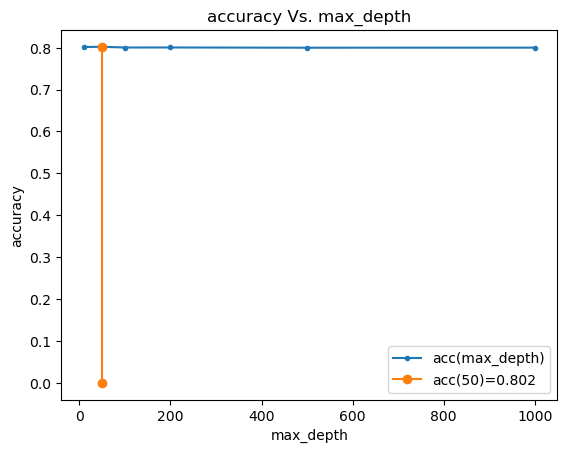

In [61]:
X,Y = LoadData("X_data.csv","Y_data.csv")
running_num = 30
maxDepth_arr = np.array([10,50,100,200,500,1000])

clf = RandomForestClassifier()
acc_total = np.array([])

for maxDepth in maxDepth_arr:
    # initial conditions
    acc = np.array([])
    clf.set_params(max_depth = maxDepth)
    for k in range(running_num):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        clf.fit(X_train,Y_train)
        acc = np.append(acc, clf.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(maxDepth_arr,acc_total,'.-')
plt.plot([maxDepth_arr[acc_total.argmax()],maxDepth_arr[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.title('accuracy Vs. max_depth')    
plt.legend(['acc(max_depth)',f'acc({maxDepth_arr[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()

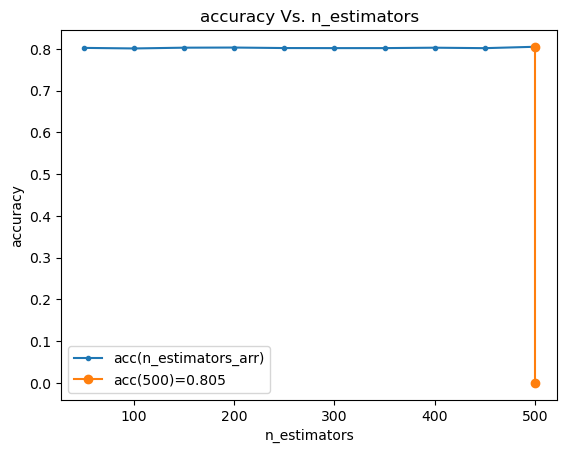

In [73]:
running_num = 30
n_estimators_arr = np.arange(50,501,50)
# inital Forest
clf = RandomForestClassifier()
acc_total = np.array([])

for n_estimators in n_estimators_arr:
    acc = np.array([])
    clf.set_params(n_estimators = n_estimators)
    for k in range(running_num):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        clf.fit(X_train,Y_train)
        acc = np.append(acc,clf.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(n_estimators_arr,acc_total,'.-')
plt.plot([n_estimators_arr[acc_total.argmax()],n_estimators_arr[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.title('accuracy Vs. n_estimators')    
plt.legend(['acc(n_estimators_arr)',f'acc({n_estimators_arr[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()

In [210]:
X,Y = LoadData("X_data.csv","Y_data.csv")
start_time = time.time()
running_num = 40
acc = np.array([])
for i in range(running_num):
    X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
    clf = RandomForestClassifier(n_estimators=100,max_depth=13,min_samples_split=10,min_samples_leaf=2).fit(X_train,Y_train)
    acc = np.append(acc,clf.score(X_test,Y_test))
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")
acc.mean()

Execution time: 17.4811 seconds


0.8034713945172826

## Optimum parameters 

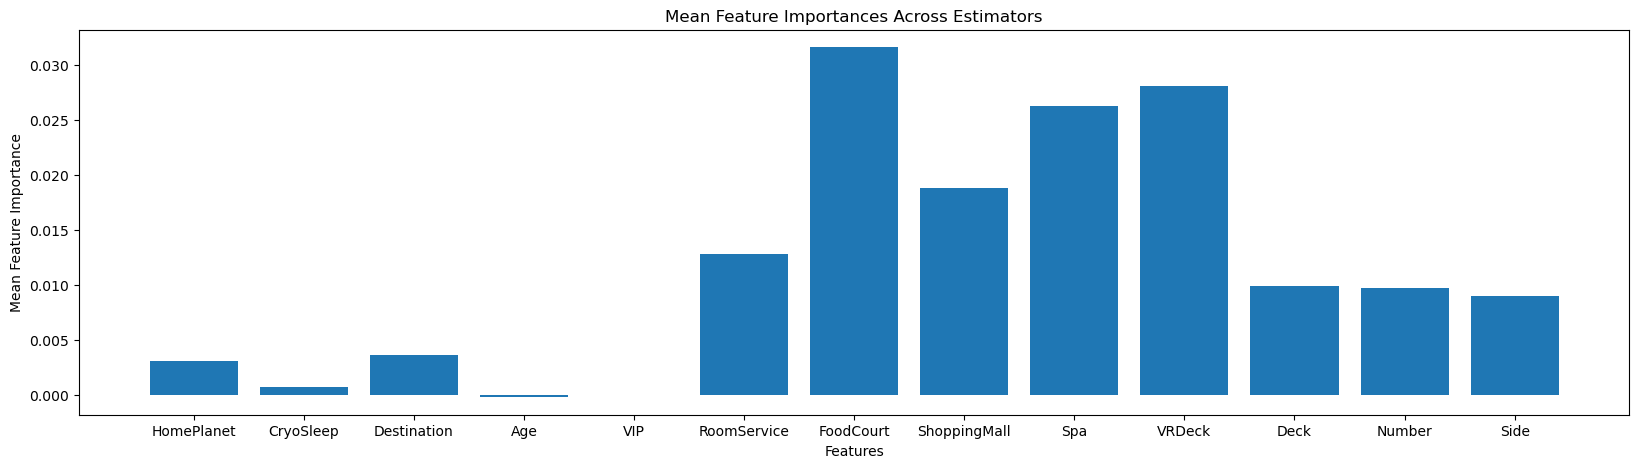

In [212]:
from sklearn.inspection import permutation_importance
feature_names = GetFeatureNames("X_data.csv")
result = permutation_importance(clf, X_test, Y_test, n_repeats=30, random_state=42)
importances = result.importances_mean

plt.figure(figsize=(20,5))
plt.bar(range(len(importances)), importances) 
plt.xticks(ticks=range(len(feature_names)),labels=feature_names)
plt.xlabel('Features')
plt.ylabel('Mean Feature Importance')
plt.title('Mean Feature Importances Across Estimators')
plt.show()